<a href="https://colab.research.google.com/github/sakram09/Spatial-Ecology-Species-Distribution-Modeling/blob/main/spatial_ecology.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Spatial Ecology & Species Distribution Modeling


Simulating Spatial Ecology occurrence data (500 GPS coordinates)...
Running K-Means Clustering for Habitat Segmentation...


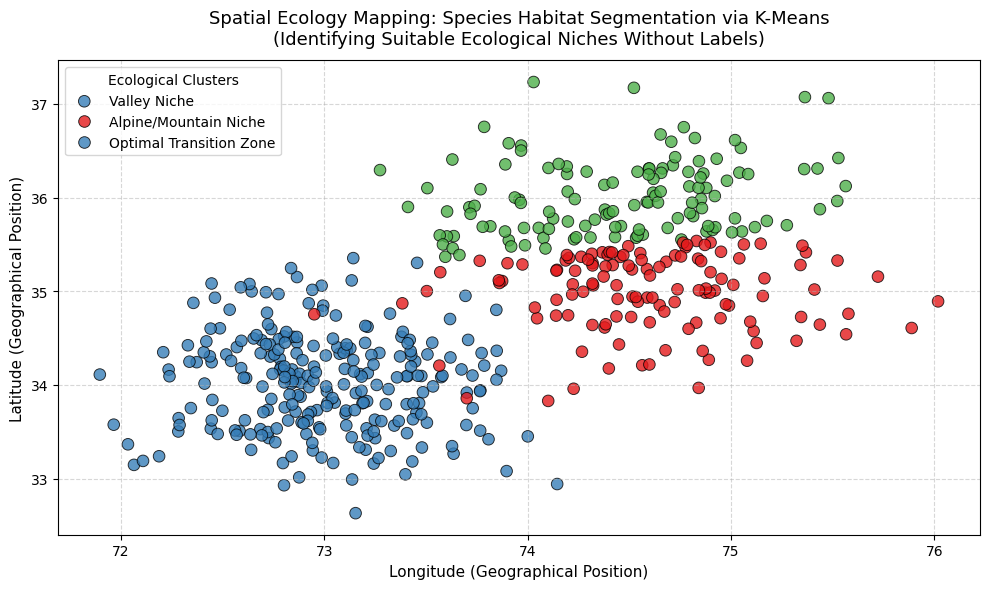


Value Counts for each habitat zone found:
Niche_Cluster
1    250
0    125
2    125
Name: count, dtype: int64


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Simulate Geographical & Climate Data for a Species (500 GPS Points)
print("Simulating Spatial Ecology occurrence data (500 GPS coordinates)...")
np.random.seed(101)
num_points = 500

# Simulate regions (e.g., mountains vs valleys)
latitudes = np.concatenate([np.random.normal(34.0, 0.5, 250), np.random.normal(35.5, 0.6, 250)])
longitudes = np.concatenate([np.random.normal(73.0, 0.4, 250), np.random.normal(74.5, 0.5, 250)])
rainfall = np.concatenate([np.random.normal(1200, 150, 250), np.random.normal(600, 100, 250)]) # mm
elevation = np.concatenate([np.random.normal(800, 200, 250), np.random.normal(2200, 300, 250)]) # meters

# Create DataFrame
spatial_df = pd.DataFrame({
    'Latitude': latitudes,
    'Longitude': longitudes,
    'Annual_Rainfall': rainfall,
    'Elevation': elevation
})

# 2. Scale features for Clustering (K-Means distance-based hota hai)
scaler_spatial = StandardScaler()
scaled_features = scaler_spatial.fit_transform(spatial_df)

# 3. Apply Unsupervised K-Means to identify 3 distinct Ecological Niches
print("Running K-Means Clustering for Habitat Segmentation...")
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
spatial_df['Niche_Cluster'] = kmeans.fit_predict(scaled_features)

# 4. PLOT: True Geographical Spatial Scatter Map
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Longitude',
    y='Latitude',
    hue='Niche_Cluster',
    palette='Set1',
    data=spatial_df,
    s=70,
    alpha=0.8,
    edgecolor='k'
)

plt.title('Spatial Ecology Mapping: Species Habitat Segmentation via K-Means\n(Identifying Suitable Ecological Niches Without Labels)', fontsize=13, pad=12)
plt.xlabel('Longitude (Geographical Position)', fontsize=11)
plt.ylabel('Latitude (Geographical Position)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Ecological Clusters', labels=['Valley Niche', 'Alpine/Mountain Niche', 'Optimal Transition Zone'])
plt.tight_layout()
plt.show()

print("\nValue Counts for each habitat zone found:")
print(spatial_df['Niche_Cluster'].value_counts())

# Spatial Clustering of Ecological Niches using K-Means

An unsupervised spatial machine learning pipeline engineered to segment wildlife habitat suitability and identify ecological niches using geographical (GPS) coordinates and macro-climatic features (Rainfall, Elevation).

## 🔬 Ecological Context
Understanding species distribution and mapping critical habitats is essential for conservation planning and reserve design. Traditional niche modeling requires extensive presence/absence labels, which are often incomplete or heavily biased in wild surveys. This pipeline utilizes unsupervised machine learning to group observation sites based purely on shared bioclimatic and spatial characteristics, successfully drawing habitat maps without human-assigned training labels.

## 💡 The Computational Approach
* **Spatial Feature Matrix:** Integrates raw latitude and longitude datasets directly with micro-climate inputs, allowing the coordinates to retain their geometric meaning.
* **Unsupervised Segmentation:** Utilizes **K-Means Clustering** to find natural cluster boundaries within multi-dimensional environmental gradients.
* **Geographical Mapping:** Directly maps the mathematically derived clusters back onto true coordinate space (Latitude vs. Longitude), bypassing abstract feature reductions like PCA and keeping the final output immediately interpretable for field ecologists.

Title: Spatial Clustering of Ecological Niches: Unsupervised Prediction of Species Habitat Suitability
The Core Idea: Ek makhsoos endangered bird ya plant species ke milne ki locations (GPS Coordinates) ka data lena aur coordinate-level climate data (Rainfall, Elevation) use karke map par clusters banana jo batayein ke kaun kaun se ilaqe us species ke rehne ke liye bilkul perfect (Suitable Niches) hain.

Asal Source Dataset: Global Biodiversity Information Facility (GBIF) ya Kaggle se kisi bhi species ka GPS occurrence data.

Desi Presentation Summary (Kia Kiya Aur Kse Kiya):
1. Data Aur Sample Size:

Total 500 unique locations (samples) ka data hai jahan wo species wild mein dekhi gayi thi.

Features: Har location ka Latitude, Longitude, Annual Rainfall (mm), aur Altitude/Elevation (meters).

2. Model Selection Aur Kyun Kiya? (The Twist):

Model: K-Means Clustering (Unsupervised Learning).

Kyun Kiya: Kyunki hamein pehle se nahi pata ke kaunsa ilaqa kaisa hai. Hum machine ko bolte hain ke coordinates aur climate data ko aapas mein jod kar 3 natural groups (Clusters) banaye:

Cluster 0: High Elevation, Low Rainfall (Alpine Niche)

Cluster 1: Low Elevation, High Rainfall (Tropical/Valley Niche)

Cluster 2: Moderate/Optimal Niche (Sab se zaroori ilaqa)

3. Visual Plot (Professor Target):

Hum seedha Latitude aur Longitude ko X aur Y axis par plot karenge (Real Map representation). Har dot ek location hogi, aur unka rang (Color) unka Cluster batayega. Isse professor ko screen par Geographical Habitat Map nazar aayega bina kisi PCA compression ke.